# Data Analysis on Emissions, Energy, and EVs

## Introduction

Climate change and the global energy transition are among the most critical challenges of our time.  
Greenhouse gas (GHG) emissions, primarily carbon dioxide (CO₂), are strongly influenced by fossil fuel consumption.  
At the same time, renewable energy production and the adoption of electric vehicles (EVs) are expected to play a major role in reducing emissions.

The goal of this project is to analyze the relationship between:
- **CO₂ emissions by country**  
- **Crude oil prices (as a proxy for fuel consumption trends)**  
- **Global renewable energy production**  

By studying these datasets both **individually** and in **combination**, we aim to answer questions such as:
- How do oil prices influence CO₂ emissions?  
- Is there a correlation between renewable energy production and CO₂ reduction?  

The analysis will involve:
1. Cleaning and preparing datasets  
2. Exploring each dataset independently  
3. Performing comparisons and correlation analysis  
4. Visualizing trends and relationships  

This project will combine **data analysis**, **visualization**, and **interpretation of results** to provide insights into the global transition toward sustainable energy.


## Problem Understanding & Objectives

### Problem Definition
Global warming and climate change are strongly driven by the use of fossil fuels and the resulting CO₂ emissions.  
At the same time, governments and industries are investing heavily in renewable energy and electric vehicles (EVs) to accelerate the transition toward sustainability.  

However, the relationships between **fuel prices**, **CO₂ emissions** and **renewable energy growth** are not straightforward.  
Understanding these correlations can provide insights into whether global energy transitions are effective in reducing emissions.

### Objectives
The main objectives of this project are:

1. **Analyze datasets individually**  
   - Explore CO₂ emissions by country  
   - Study crude oil price trends  
   - Examine renewable energy production  

2. **Compare datasets to find relationships**  
   - Test correlation between fuel prices and CO₂ emissions  
   - Compare renewable energy growth against emissions reductions  

3. **Visualize insights**  
   - Use graphs and plots to clearly show trends, correlations, and comparisons  

4. **Draw conclusions**  
   - Summarize whether the data supports the hypothesis that renewable energy adoption contributes to lower CO₂ emissions, and how oil prices interact with these variables.


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import matplotlib.ticker as mtick

## Data Description

For this project, we use four independent datasets, each covering a different but related aspect of the global energy and emissions landscape:

1. **CO₂ Emissions by Country**  
   - Source: Kaggle ([CO₂ Emissions by Country](https://www.kaggle.com/datasets/ulrikthygepedersen/co2-emissions-by-country))  
   - Contains annual CO₂ emissions data by country, measured in metric tons.  
   - Provides a global perspective on how emissions have changed over time.

2. **Crude Oil Price**  
   - Source: Kaggle ([Crude Oil Price](https://www.kaggle.com/datasets/sc231997/crude-oil-price))  
   - Historical dataset of crude oil prices.  
   - Used to study the relationship between oil price fluctuations and CO₂ emissions / energy transition trends.

3. **Global Data on Sustainable Energy**  
   - Source: Kaggle ([Global Data on Sustainable Energy](https://www.kaggle.com/datasets/anshtanwar/global-data-on-sustainable-energy))  
   - Includes data on renewable energy production and consumption by country and year.  
   - Useful for analyzing how clean energy adoption relates to emissions reductions.


### Why These Datasets?
The combination of these four datasets allows us to explore multiple dimensions of the global energy transition:
- Oil dependency (via fuel prices),
- Climate impact (via CO₂ emissions),
- Clean alternatives (via renewable energy)

This multi-angle approach provides a more complete picture than analyzing any single dataset alone.


## CO2 Emissions Preprocessing & Cleaning


### 1. Overview

Before we can analyze the CO₂ emissions dataset, we need to ensure it is clean and structured properly. 
This involves handling missing values, correcting data types, removing duplicates, and preparing the dataset for analysis.


### 2. Loading the Dataset

First, we load the dataset and inspect the first few rows to understand its structure and contents.


In [2]:
# Load the dataset
df_co2 = pd.read_csv('co2_emissions_kt_by_country.csv')

# Display first few rows
df_co2.head()


,country_code,country_name,year,value
0,ABW,Aruba,1960,11092.675
1,ABW,Aruba,1961,11576.719
2,ABW,Aruba,1962,12713.489
3,ABW,Aruba,1963,12178.107
4,ABW,Aruba,1964,11840.743


### 3. Inspecting the Data

We check the dataset's dimensions, column names, and look for any missing values.


In [3]:
# Check the shape of the dataset
print("Dataset shape:", df_co2.shape)

# Check for missing values
print("\nMissing values per column:\n", df_co2.isnull().sum())

# Check data types
print("\nData types:\n", df_co2.dtypes)


Dataset shape: (13953, 4)

Missing values per column:
 country_code    0
country_name    0
year            0
value           0
dtype: int64

Data types:
 country_code     object
country_name     object
year              int64
value           float64
dtype: object


### 4. Removing Duplicates

Even though the dataset appears clean, we should check for duplicate rows 
and remove them if they exist to ensure our analysis is accurate.


In [5]:
# Remove duplicate rows
df_co2.drop_duplicates(inplace=True)

# Verify duplicates removed
print("Number of duplicate rows:", df_co2.duplicated().sum())


Number of duplicate rows: 0


### 5. Renaming Columns

For clarity, we rename the 'value' column to 'CO2_Emissions' 
so it better describes the data it contains.


In [6]:
# Rename 'value' to 'CO2_Emissions'
df_co2.rename(columns={'value': 'CO2_Emissions'}, inplace=True)

# Check the first few rows
df_co2.head()


,country_code,country_name,year,CO2_Emissions
0,ABW,Aruba,1960,11092.675
1,ABW,Aruba,1961,11576.719
2,ABW,Aruba,1962,12713.489
3,ABW,Aruba,1963,12178.107
4,ABW,Aruba,1964,11840.743


### 6. Data Types Confirmation

We confirm that all columns have appropriate data types for analysis:
- 'year' should be integer
- 'CO2_Emissions' should be numeric
- 'country_code' and 'country_name' should be categorical/objects


In [7]:
# Confirm data types
df_co2.dtypes


country_code      object
country_name      object
year               int64
CO2_Emissions    float64
dtype: object

### 7. Exploratory Data Analysis (EDA)

Now that the dataset is clean, we can explore CO₂ emissions:
- Look at distribution of emissions
- Identify trends over years
- Compare emissions between countries


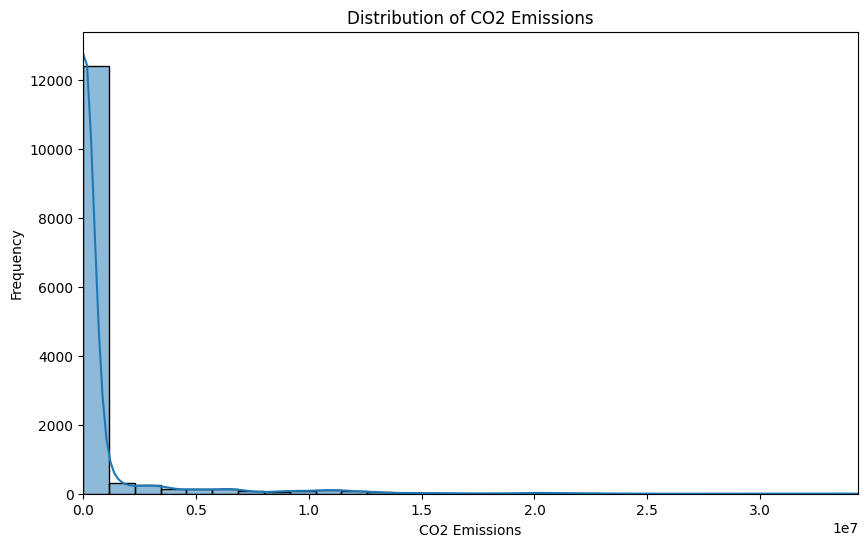

In [9]:
plt.figure(figsize=(10,6))
sns.histplot(df_co2['CO2_Emissions'], bins=30, kde=True)
plt.title('Distribution of CO2 Emissions')
plt.xlabel('CO2 Emissions')
plt.ylabel('Frequency')

# Set x-axis from minimum to maximum value in your dataset
plt.xlim(df_co2['CO2_Emissions'].min(), df_co2['CO2_Emissions'].max())

plt.show()



In [10]:
df_co2['CO2_Emissions'].head(20)


0     11092.675
1     11576.719
2     12713.489
3     12178.107
4     11840.743
5     10623.299
6      9933.903
7     12236.779
8     11378.701
9     14891.687
10    16655.514
11    14495.651
12    14055.611
13    15592.084
14    14132.618
15    10234.597
16    21862.654
17    11419.038
18     9724.884
19    10201.594
Name: CO2_Emissions, dtype: float64

In [16]:
df_co2['CO2_Emissions'].isnull().count()


np.int64(13953)

In [12]:
df_co2['CO2_Emissions'].describe()


count    1.395300e+04
mean     8.254983e+05
std      2.788923e+06
min     -8.067400e+01
25%      1.100000e+03
50%      1.390000e+04
75%      1.642779e+05
max      3.434401e+07
Name: CO2_Emissions, dtype: float64

In [13]:
# Sort CO2_Emissions in ascending order
df_co2_sorted = df_co2['CO2_Emissions'].sort_values()
df_co2_sorted.head(20)  # show the 20 smallest values


11002   -80.674
3692      0.000
12460     0.000
3693      0.000
12469     0.000
12462     0.000
12461     0.000
12459     0.000
12466     0.000
12468     0.000
12470     0.000
12467     0.000
12464     0.000
12465     0.000
12463     0.000
4229      0.000
4230      0.000
8166      0.000
8321      0.000
8165      0.000
Name: CO2_Emissions, dtype: float64

#### Analysis of CO2 Emissions Distribution

Initially, we plotted a histogram of the `CO2_Emissions` column using all the data. However, the resulting graph was misleading:

- The most frequent value appeared as **0.0** with an extremely high frequency.
- About 99% of the values seemed to lie below **500000**, which did not align with realistic country-level emissions.
- The descriptive statistics showed:
  - Minimum: -80 (likely invalid)
  - Maximum: 34,344,010
  - Median: 13,900

**Observations:**
1. The dataset contains **negative values**, which are not physically meaningful for CO2 emissions and likely represent data errors.
2. There are **extreme outliers** (up to 34 million), which compress the bulk of the data when plotting the histogram, making most countries appear as if they emit almost nothing.
3. The automatic binning in the histogram causes the bulk of realistic values to appear very small on the x-axis.

**Solution:**
- Filter out negative values to remove invalid data.
- Limit the x-axis to a reasonable range, such as up to the 99th percentile, to reduce the effect of extreme outliers.
- This allows the histogram to accurately represent the distribution of the majority of countries.


count    1.393100e+04
mean     8.268020e+05
std      2.790932e+06
min      3.667000e+00
25%      1.120000e+03
50%      1.401527e+04
75%      1.645921e+05
max      3.434401e+07
Name: CO2_Emissions, dtype: float64


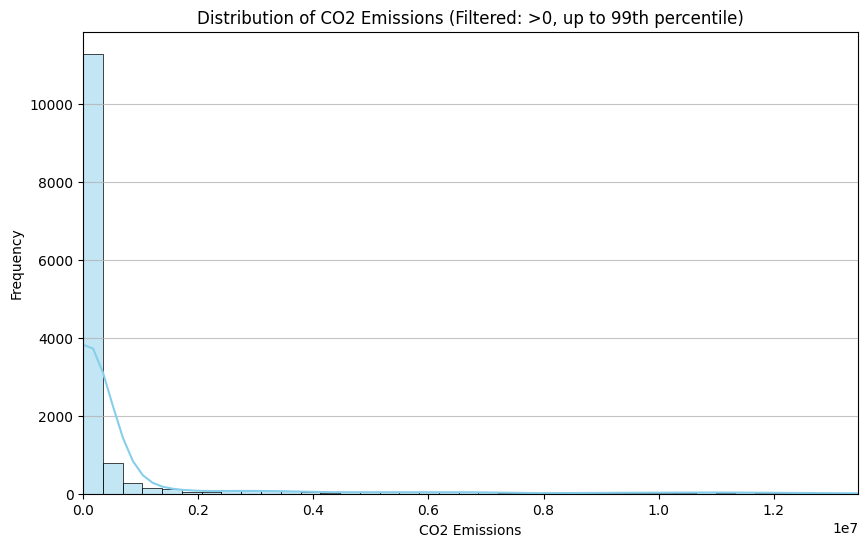

In [17]:
# Step 1: Remove negative and zero values
df_co2_filtered = df_co2[df_co2['CO2_Emissions'] > 1]

# Optional: limit to 99th percentile to avoid extreme outliers
upper_limit = df_co2_filtered['CO2_Emissions'].quantile(0.99)

# Step 2: Summary stats for filtered data
print(df_co2_filtered['CO2_Emissions'].describe())

# Step 3: Plot histogram
plt.figure(figsize=(10,6))
sns.histplot(df_co2_filtered['CO2_Emissions'], bins=100, kde=True, color='skyblue')
plt.title('Distribution of CO2 Emissions (Filtered: >0, up to 99th percentile)')
plt.xlabel('CO2 Emissions')
plt.ylabel('Frequency')
plt.xlim(0, upper_limit)
plt.grid(axis='y', alpha=0.75)
plt.show()


#### Focusing on High CO2 Emission Values

Even after removing zeros and negative values, the histogram still peaks near 0–0.2 million CO2 emissions, while the majority of higher-emitting countries appear as a flatline. This happens because:

1. **Most countries have relatively low emissions**, so when plotted on the same scale as the largest emitters, the distribution of medium- and high-emission countries gets compressed near the x-axis.
2. **Extreme outliers** (countries with very high emissions) skew the histogram, making smaller differences among high-emission countries invisible.

**Solution:**
- To better visualize the distribution of countries with significant CO2 emissions, we will filter the dataset to include only countries with emissions above a certain threshold (e.g., 200,000 or 250,000).
- This allows us to **focus on medium- and high-emitting countries**, giving a more meaningful view of the variation among them.

Filtering in this way does **not remove valid data**, it just changes the scale of the visualization so we can better interpret patterns among the highest emitters.


Rows after filter: 3006


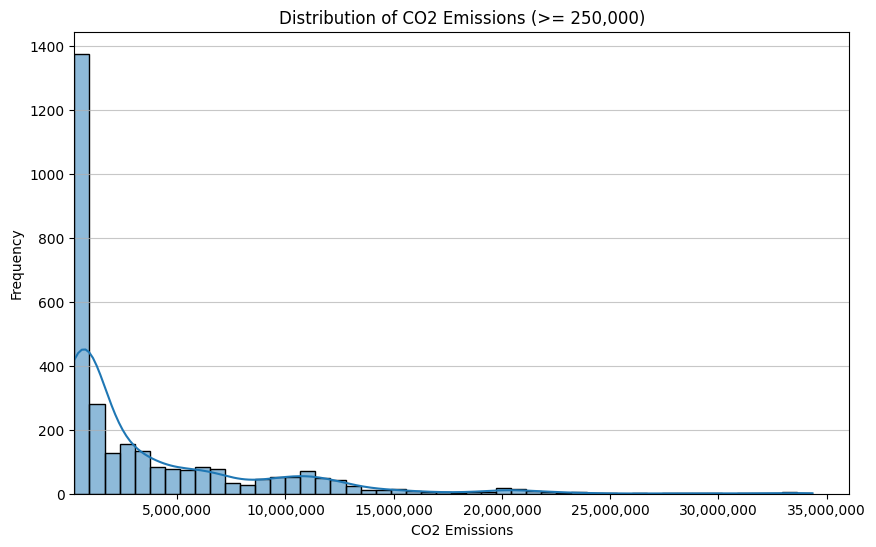

In [22]:
# Filter out zeros/negatives first
df_co2_filtered = df_co2[df_co2['CO2_Emissions'] > 0]

# Further filter for the region we want to inspect
left_bound = 250_000
df_co2_high = df_co2_filtered[df_co2_filtered['CO2_Emissions'] >= left_bound]


print("Rows after filter:", len(df_co2_high))
if df_co2_high.empty:
    print("No rows >= {:,}. Nothing to plot.".format(left_bound))
else:
    right_bound = df_co2_high['CO2_Emissions'].max()
    # Create explicit bin edges that start exactly at left_bound
    bins = np.linspace(left_bound, right_bound, 50)  # 30 bins between left and right

    # Plot into an axes object and then lock the axis limits
    fig, ax = plt.subplots(figsize=(10,6))
    sns.histplot(df_co2_high['CO2_Emissions'], bins=bins, kde=True, ax=ax)

    # Force the x-axis bounds and prevent autoscaling from changing them
    ax.set_xlim(left_bound)
    ax.set_xbound(left_bound)
    ax.set_autoscale_on(False)  # stop further autoscaling

    # nicer x tick formatting (thousands separator)
    ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"{int(x):,}"))

    ax.set_title(f'Distribution of CO2 Emissions (>= {left_bound:,})')
    ax.set_xlabel('CO2 Emissions')
    ax.set_ylabel('Frequency')
    ax.grid(axis='y', alpha=0.7)

    plt.show()

#### Analysis of High-Emission Countries

After filtering the dataset to only include CO2 emissions greater than 250,000, the histogram gives us a clearer view of the distribution of medium- and high-emission countries.

**Key points:**
1. Most of the countries in this subset fall within the lower end of the high-emission spectrum (just above 250,000).
2. The frequency decreases as emissions increase, but there are still a few countries with extremely large values (close to the right boundary of the graph).
3. This indicates a **right-skewed distribution**, where a small number of countries contribute disproportionately high emissions compared to the majority.

**Conclusion:**
- The majority of high-emitting countries cluster closer to the lower threshold (250,000–1,000,000).
- Outliers exist with much higher emissions, which highlights the unequal distribution of CO2 emissions globally.


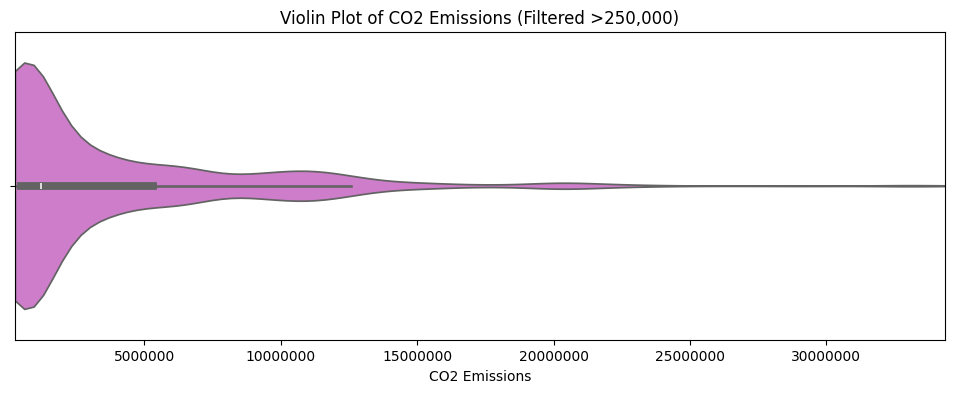

In [23]:
plt.figure(figsize=(12,4))
sns.violinplot(
    x=df_co2_high['CO2_Emissions'],
    color='orchid',
    cut=0
)

plt.title('Violin Plot of CO2 Emissions (Filtered >250,000)')
plt.xlabel('CO2 Emissions')

# Start x-axis at 250,000
plt.xlim(250000, df_co2_high['CO2_Emissions'].max())

# Remove scientific notation
plt.ticklabel_format(style='plain', axis='x')

plt.show()

#### Violin Plot of CO₂ Emissions (Filtered >250,000)

To better visualize the distribution of very high CO₂ emissions, we used a **violin plot**.  
- The x-axis starts at **250,000**, avoiding the distortion caused by smaller values.
- The shape of the violin highlights where emissions are most densely concentrated, while still showing the long tail of extreme outliers.  

This provides a smoother and more intuitive view compared to a boxplot, which can appear distorted with highly skewed data.


#### Global CO₂ Emissions Over Time

The dataset also includes summary rows where `country_name` is set to **"World"**, representing the total global CO₂ emissions for each year.  
To better understand the global trend, we isolate these rows and plot emissions across time.  

This allows us to compare individual country emissions with the overall global emissions and see how worldwide output has evolved historically.


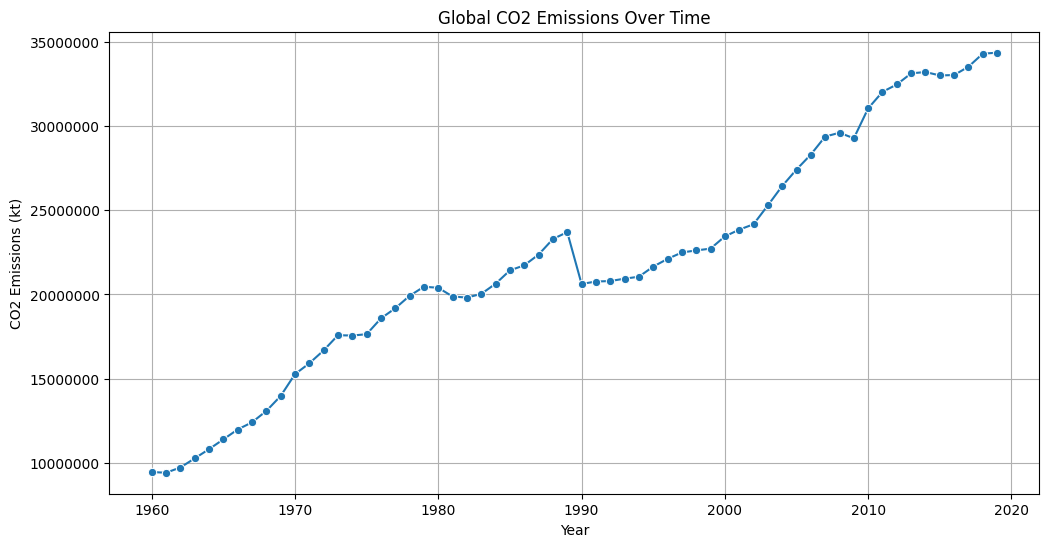

In [24]:
# Filter dataset for World summary values
df_co2_world = df_co2[df_co2['country_name'] == 'World']

# Plot CO2 emissions over time for the world
plt.figure(figsize=(12,6))
sns.lineplot(data=df_co2_world, x='year', y='CO2_Emissions', marker='o')

plt.title('Global CO2 Emissions Over Time')
plt.xlabel('Year')
plt.ylabel('CO2 Emissions (kt)')
plt.ticklabel_format(style='plain', axis='y')  # remove scientific notation
plt.grid(True)

plt.show()


#### Why Did Global Emissions Drop in 1990?

After spotting a sharp decline in global CO₂ emissions between **1989 and 1990**, 
I looked at specific country data.  

For example, Russia (formerly part of the Soviet Union) shows a dramatic fall:  


#### Russia’s CO₂ Emissions (1980–2000)

The chart below shows Russia’s emissions over two decades.  
From 1980 to 1989, emissions were stable at very high levels, close to **4,000,000 kt**.  
In **1990**, emissions collapsed by nearly half, and remained low throughout the 1990s.  

This sharp drop aligns with the **economic and industrial collapse** following the 
end of the Soviet Union, which strongly influenced the global emissions total.

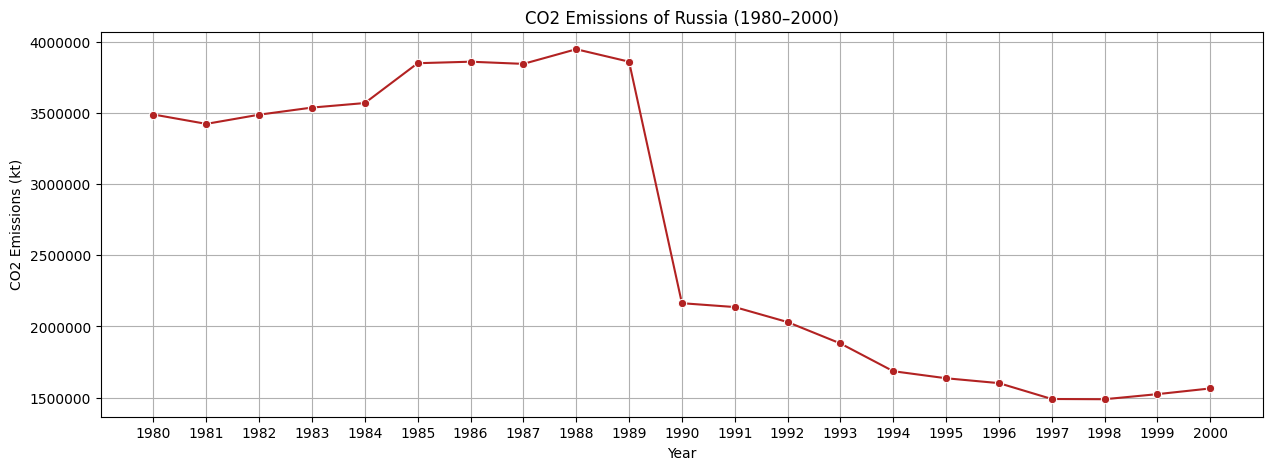

In [26]:
# Filter Russia data between 1980 and 2000
df_co2_russia_long = df_co2[
    (df_co2['country_code'] == 'RUS') &
    (df_co2['year'].between(1980, 2000))
]

# Plot line chart
plt.figure(figsize=(15,5))
sns.lineplot(data=df_co2_russia_long, x='year', y='CO2_Emissions', marker='o', color='firebrick')

plt.title('CO2 Emissions of Russia (1980–2000)')
plt.xlabel('Year')
plt.ylabel('CO2 Emissions (kt)')
plt.ticklabel_format(style='plain', axis='y')  # remove scientific notation
plt.grid(True)

# Fix x-axis ticks: show every year
plt.xticks(np.arange(1980, 2001, 1))

plt.show()


This single change represents a drop of nearly **1.7 million kt**, 
which is enough to significantly influence the global totals.  

The timing coincides with the **collapse of the Soviet Union** and the 
economic/industrial breakdown in Eastern Europe and Russia.  
This confirms that the global decline was driven not by gradual 
environmental policy, but by a sudden geopolitical and economic shock. 

### 8. Conclusion on CO₂ Emissions Dataset

From the analysis, several key insights emerged:

1. **Data quality issues:**  
   - Some rows contained `0` or even negative values.  
   - The dataset also included aggregated regions and income groups, which overlap with country totals.  
   - These anomalies had to be filtered or acknowledged to avoid misleading results.  

2. **Global emissions trends:**  
   - The global emissions chart shows steady growth through most of the 20th century,  
     with a sharp drop in **1990**.  
   - Investigation revealed that this was largely driven by the collapse of the **Soviet Union**,  
     where Russia’s emissions fell dramatically as industry contracted.  

3. **Historical context:**  
   - The 1990 drop was not a result of environmental policies but of **geopolitical and economic events**.  
   - This demonstrates how political change can have as much impact on global emissions as policy or technology.  

**Next steps:**  
We will now proceed to analyze the next dataset to compare or complement these findings.


## Crude Oil Price

### Loading and Inspecting the Crude Oil Price Dataset

We'll begin by loading the dataset and inspecting its structure to understand the columns and identify any potential issues.


In [28]:
# Load the dataset
df_oil = pd.read_csv('crude-oil-price.csv')

# Display the first few rows and column names
print("Columns:", list(df_oil.columns))
print("\nFirst 5 rows:")
display(df_oil.head())

Columns: ['date', 'price', 'percentChange', 'change']

First 5 rows:


,date,price,percentChange,change
0,1983-03-01 00:00:00+00:00,29.27,NaN,NaN
1,1983-04-01 00:00:00+00:00,30.63,4.646,1.36
2,1983-05-01 00:00:00+00:00,30.25,-1.241,-0.38
3,1983-06-01 00:00:00+00:00,31.38,3.736,1.13
4,1983-07-01 00:00:00+00:00,32.00,1.976,0.62


### Cleaning the Crude Oil Price Data

We'll clean the dataset by:
- Renaming columns for clarity.
- Converting the 'date' column to datetime format.
- Handling any missing or duplicate values.


In [29]:
# Ensure 'date' column is datetime
df_oil['date'] = pd.to_datetime(df_oil['date'])

# Check for missing values
print("Missing values per column:")
print(df_oil.isnull().sum())

# Drop rows with missing prices (if any)
df_oil = df_oil.dropna(subset=['price'])

# Reset index after dropping rows
df_oil = df_oil.reset_index(drop=True)


# Quick check of first 5 rows
df_oil.head()

Missing values per column:
date             0
price            0
percentChange    1
change           1
dtype: int64


,date,price,percentChange,change
0,1983-03-01 00:00:00+00:00,29.27,NaN,NaN
1,1983-04-01 00:00:00+00:00,30.63,4.646,1.36
2,1983-05-01 00:00:00+00:00,30.25,-1.241,-0.38
3,1983-06-01 00:00:00+00:00,31.38,3.736,1.13
4,1983-07-01 00:00:00+00:00,32.00,1.976,0.62


In [30]:
df_oil_sorted = df_oil['price'].sort_values()
df_oil_sorted.tail()

337    113.93
305    115.46
304    124.08
302    127.35
303    140.00
Name: price, dtype: float64

### Inspect Descriptive Statistics

Now that the dataset is cleaned and all missing values in the `price` column are handled, we can examine basic descriptive statistics.  

This includes:  
- Mean, median, min, max  
- Standard deviation  
- Noting any extreme values that could influence analysis  

Observing these statistics will give us a sense of the distribution of crude oil prices over time.  
In particular, we already notice that the highest price exceeds 140 USD/Bbl, which is well above the average — something to investigate further in the visualization step.


In [31]:
# Descriptive statistics for crude oil prices
price_stats = df_oil['price'].describe()
price_stats


count    510.000000
mean      46.767957
std       28.847577
min       10.420000
25%       20.530000
50%       35.775000
75%       69.682500
max      140.000000
Name: price, dtype: float64

In [32]:
# check the highest values
highest_prices = df_oil.sort_values(by='price', ascending=False).head(10)
highest_prices[['date', 'price']]


,date,price
303,2008-06-01 00:00:00+00:00,140.00
302,2008-05-01 00:00:00+00:00,127.35
304,2008-07-01 00:00:00+00:00,124.08
305,2008-08-01 00:00:00+00:00,115.46
337,2011-04-01 00:00:00+00:00,113.93
301,2008-04-01 00:00:00+00:00,113.46
470,2022-05-01 00:00:00+00:00,111.91
365,2013-08-01 00:00:00+00:00,107.65
347,2012-02-01 00:00:00+00:00,107.07
336,2011-03-01 00:00:00+00:00,106.72


### Yearly Crude Oil Price Trends with Volatility

To better understand crude oil price trends and volatility, we aggregate the monthly data by year.  

- The main line shows the **average price per year**.  
- The shaded area represents the **price spread**: minimum to maximum price within each year.  

This visualization highlights both long-term trends and periods of high volatility.


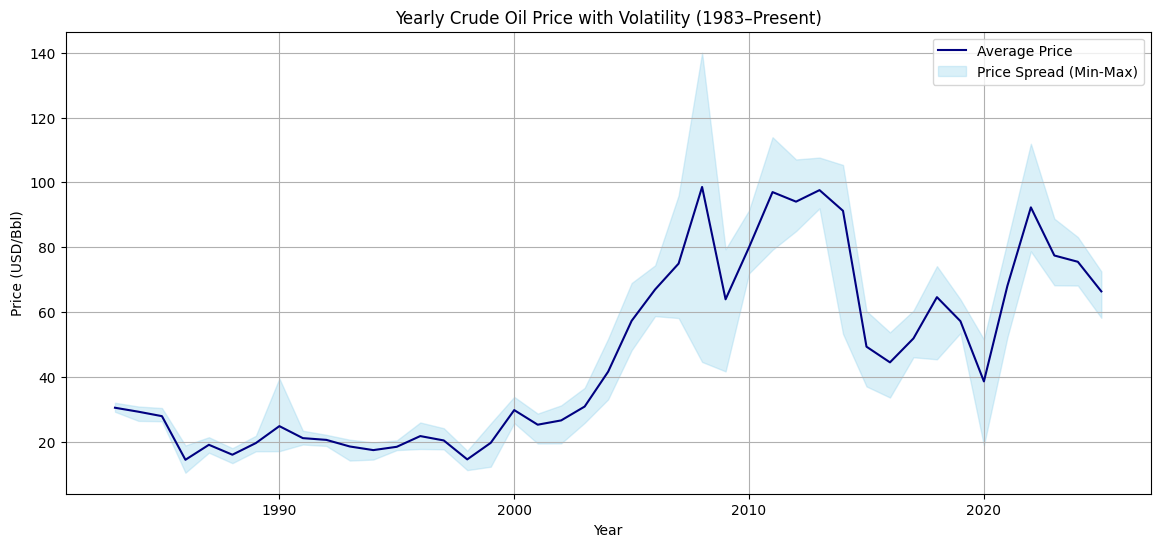

In [33]:
# Extract year from date
df_oil['year'] = df_oil['date'].dt.year

# Group by year: calculate mean, min, max
yearly_stats = df_oil.groupby('year')['price'].agg(['mean', 'min', 'max']).reset_index()

# Plot
plt.figure(figsize=(14,6))

# Main line: yearly average
plt.plot(yearly_stats['year'], yearly_stats['mean'], color='navy', label='Average Price')

# Fill between min and max to show volatility
plt.fill_between(yearly_stats['year'], yearly_stats['min'], yearly_stats['max'],
                 color='skyblue', alpha=0.3, label='Price Spread (Min-Max)')

# Titles and labels
plt.title('Yearly Crude Oil Price with Volatility (1983–Present)')
plt.xlabel('Year')
plt.ylabel('Price (USD/Bbl)')
plt.grid(True)
plt.legend()

# Remove scientific notation on y-axis
plt.ticklabel_format(style='plain', axis='y')

plt.show()


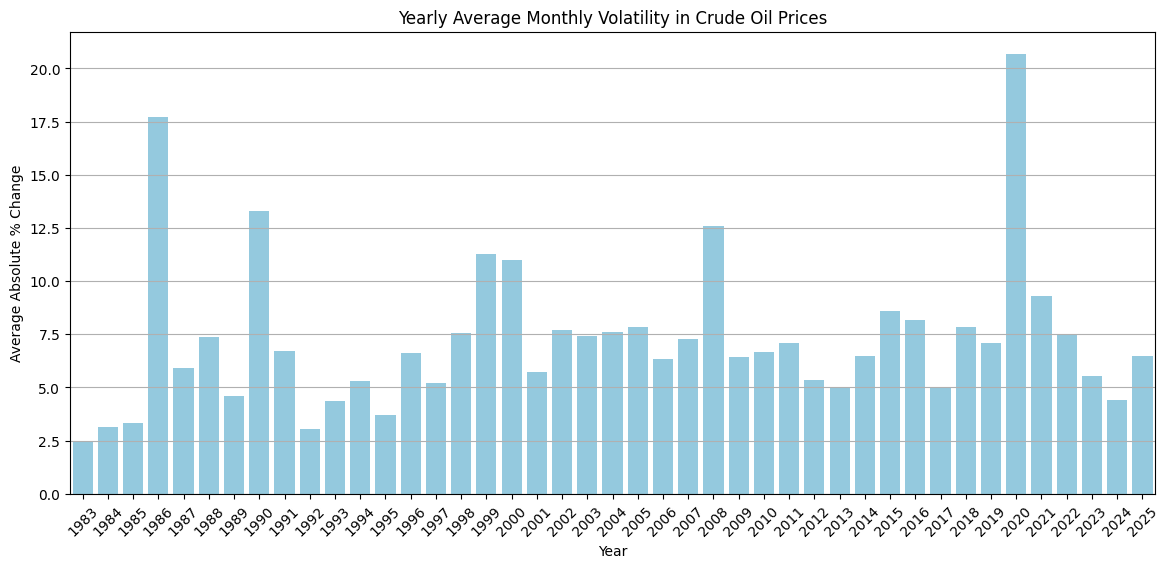

In [34]:
# Absolute monthly percent change
df_oil['abs_percent_change'] = df_oil['percentChange'].abs()

# Group by year: average absolute percent change
yearly_volatility = df_oil.groupby('year')['abs_percent_change'].mean().reset_index()

# Plot bar chart
plt.figure(figsize=(14,6))
sns.barplot(data=yearly_volatility, x='year', y='abs_percent_change', color='skyblue')
plt.xticks(rotation=45)
plt.title('Yearly Average Monthly Volatility in Crude Oil Prices')
plt.xlabel('Year')
plt.ylabel('Average Absolute % Change')
plt.grid(axis='y')
plt.show()


### Analyzing Price Volatility in Key Periods

We will examine the monthly price changes during three major events to quantify volatility:

#### 2008 Spike
- Prices surged to nearly **140 USD/Bbl**, with large month-to-month percentage changes.
- Driven by **financial speculation, strong global demand, and geopolitical tensions**, followed by the **global financial crisis**, which caused prices to collapse later in the year.

#### 2015 Drop
- Prices fell sharply due to **increased oil supply (US shale boom), OPEC's decision not to cut production, and weaker global demand growth**.
- Monthly percentage changes show how quickly the market adjusted to these factors.

#### 2020 COVID-19 Crash
- The COVID-19 pandemic caused **global lockdowns**, drastically reducing demand for oil.
- Prices dropped rapidly, even turning **negative for WTI futures in April 2020**, showing extreme volatility in a short period.
- Monthly percentage changes illustrate the severity and rapidity of this shock.

#### Following the COVID-19 crash, crude oil prices experienced a **rapid rebound**:

- As lockdowns eased globally, demand for oil surged, but supply was still constrained due to OPEC+ production limits and slow ramp-up from other producers.
- Prices rose sharply from mid-2020 into 2021, demonstrating the **market's quick reaction to demand recovery**.
- Monthly percent changes in this period also show high volatility, though in a strong upward trend.

We will visualize these periods to highlight the extremes and volatility in the market.



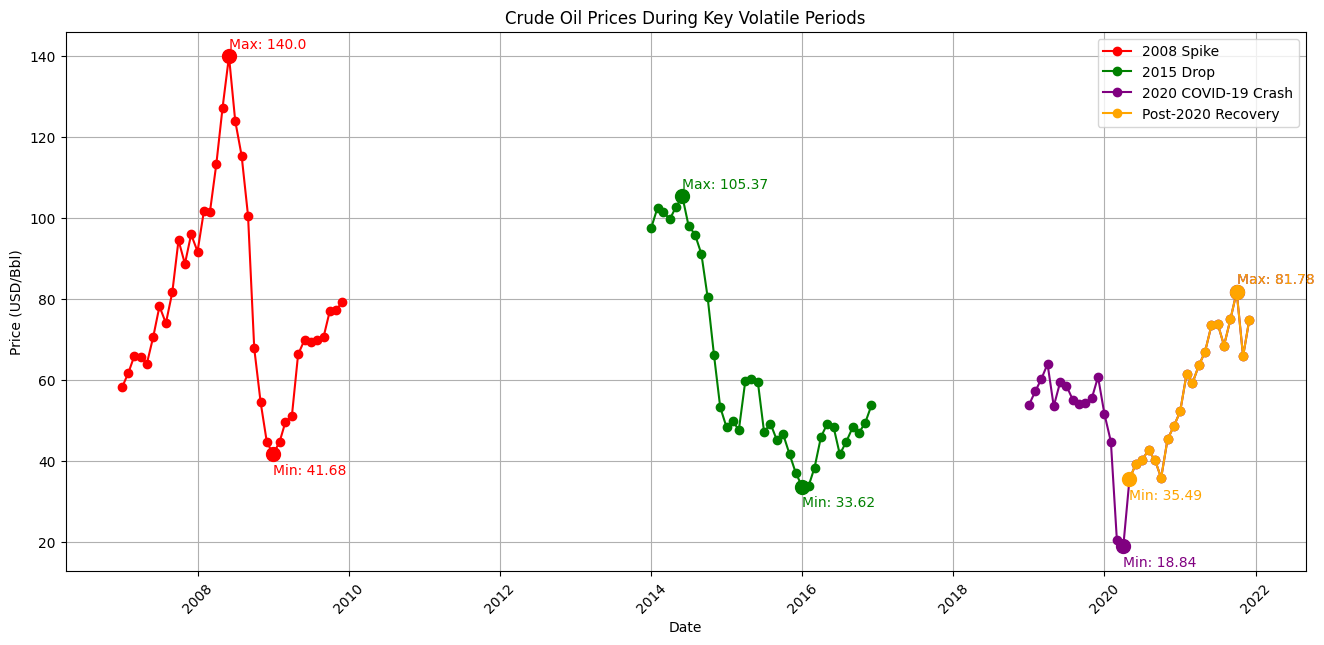

In [35]:
# Filter periods
df_oil_2008 = df_oil[df_oil['year'].between(2007, 2009)]
df_oil_2015 = df_oil[df_oil['year'].between(2014, 2016)]
df_oil_2020 = df_oil[df_oil['year'].between(2019, 2021)]
df_oil_recovery = df_oil[df_oil['date'].between('2020-05-01', '2021-12-31')]

# Plot
plt.figure(figsize=(16,7))

# Plot each period
plt.plot(df_oil_2008['date'], df_oil_2008['price'], marker='o', linestyle='-', color='red', label='2008 Spike')
plt.plot(df_oil_2015['date'], df_oil_2015['price'], marker='o', linestyle='-', color='green', label='2015 Drop')
plt.plot(df_oil_2020['date'], df_oil_2020['price'], marker='o', linestyle='-', color='purple', label='2020 COVID-19 Crash')
plt.plot(df_oil_recovery['date'], df_oil_recovery['price'], marker='o', linestyle='-', color='orange', label='Post-2020 Recovery')

# Highlight maximum and minimum points for each period
for df_oil_period, color in zip([df_oil_2008, df_oil_2015, df_oil_2020, df_oil_recovery], ['red', 'green', 'purple', 'orange']):
    max_row = df_oil_period.loc[df_oil_period['price'].idxmax()]
    min_row = df_oil_period.loc[df_oil_period['price'].idxmin()]
    plt.scatter(max_row['date'], max_row['price'], color=color, s=100, zorder=5)
    plt.text(max_row['date'], max_row['price']+2, f"Max: {max_row['price']}", color=color)
    plt.scatter(min_row['date'], min_row['price'], color=color, s=100, zorder=5)
    plt.text(min_row['date'], min_row['price']-5, f"Min: {min_row['price']}", color=color)

# Titles, labels, grid
plt.title('Crude Oil Prices During Key Volatile Periods')
plt.xlabel('Date')
plt.ylabel('Price (USD/Bbl)')
plt.grid(True)
plt.legend()
plt.xticks(rotation=45)

plt.show()

## Comparing CO₂ Emissions with Crude Oil Prices

In this step, we aim to explore the relationship between **global CO₂ emissions** and **crude oil prices**.  

- Both datasets cover overlapping years, but we will **limit the analysis to 1983 onward** to match the start of the crude oil dataset.  
- We will create a **dual y-axis line chart**:
  - **Left y-axis:** CO₂ emissions (kt)  
  - **Right y-axis:** Average yearly crude oil price (USD/Bbl)  
- This visualization allows us to **observe potential correlations** between oil price fluctuations and CO₂ emissions trends.  

Key points to note:
- Periods of extreme oil price volatility (like 2008, 2015, 2020) can be examined in relation to changes in emissions.  
- The analysis will help us understand whether **oil price shocks have a visible effect on global emissions**, which could indicate links between economic activity, fuel costs, and industrial output.


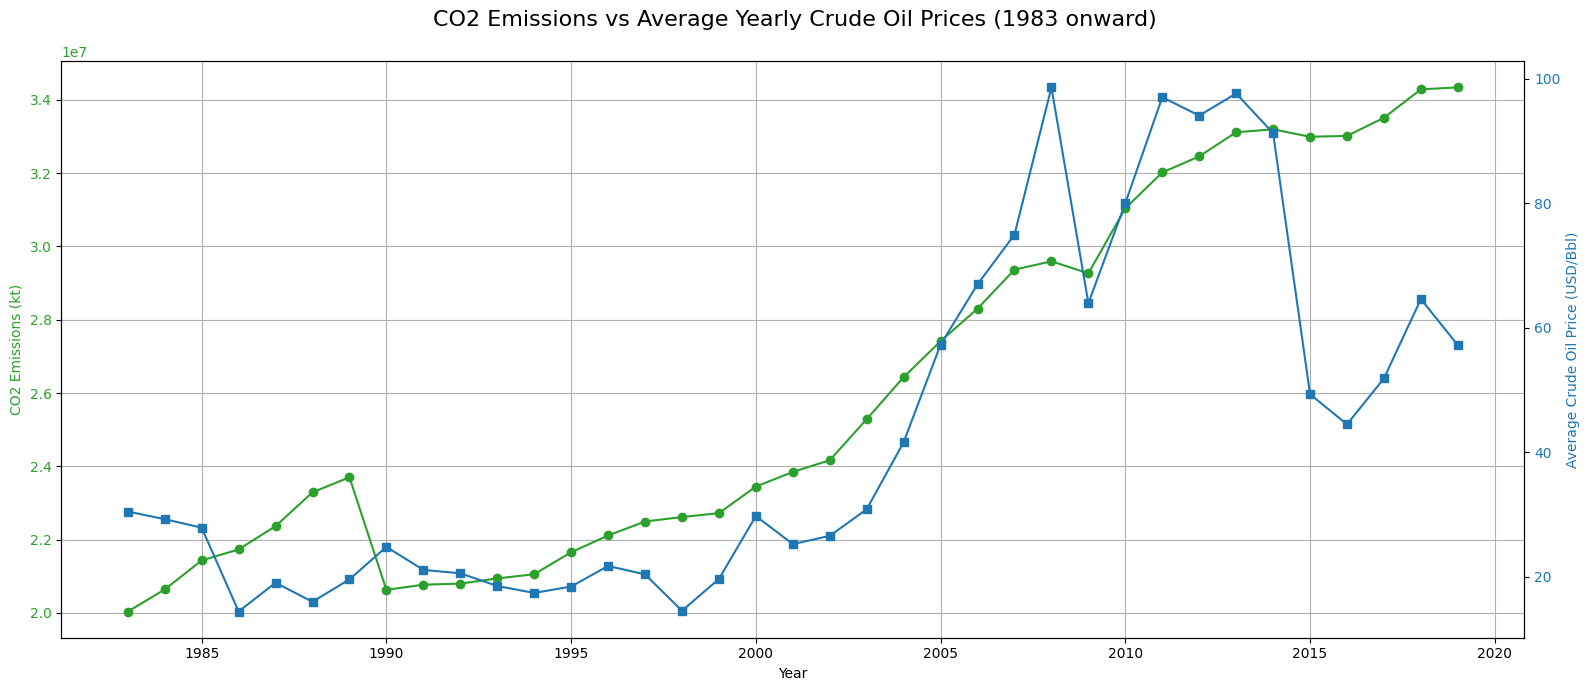

In [36]:
# 1. Filter CO2 dataset for 1983 onward and for "World" data only
df_co2_world = df_co2[(df_co2['year'] >= 1983) & (df_co2['country_name'] == 'World')]

# 2. Aggregate CO2 emissions by year
co2_yearly = df_co2_world[['year', 'CO2_Emissions']].copy()

# 3. Aggregate oil prices by year (average)
oil_yearly = df_oil[df_oil['year'] >= 1983].groupby('year')['price'].mean().reset_index()

# 4. Merge datasets on year
merged_df = pd.merge(co2_yearly, oil_yearly, on='year')

# 5. Plot dual y-axis
fig, ax1 = plt.subplots(figsize=(16,7))

# CO2 emissions on left y-axis
color_co2 = 'tab:green'
ax1.set_xlabel('Year')
ax1.set_ylabel('CO2 Emissions (kt)', color=color_co2)
ax1.plot(merged_df['year'], merged_df['CO2_Emissions'], color=color_co2, marker='o', label='CO2 Emissions')
ax1.tick_params(axis='y', labelcolor=color_co2)
ax1.grid(True)

# Oil price on right y-axis
ax2 = ax1.twinx()
color_oil = 'tab:blue'
ax2.set_ylabel('Average Crude Oil Price (USD/Bbl)', color=color_oil)
ax2.plot(merged_df['year'], merged_df['price'], color=color_oil, marker='s', label='Crude Oil Price')
ax2.tick_params(axis='y', labelcolor=color_oil)

# Titles and legend
fig.suptitle('CO2 Emissions vs Average Yearly Crude Oil Prices (1983 onward)', fontsize=16)
fig.tight_layout()
plt.show()

### Analysis of CO₂ Emissions vs Crude Oil Prices

Observations from the dual-axis chart:

**Long-term trend:**  
- CO₂ emissions show a mostly steady upward trend over the decades, reflecting industrial growth and energy consumption.  
- Crude oil prices fluctuate much more dramatically month-to-month and year-to-year, showing spikes and crashes due to supply-demand shocks, geopolitical events, or financial crises.

**Short-term disconnects:**  
- Some major oil price movements don’t immediately affect CO₂ emissions, e.g., the 2015 oil price drop didn’t cause an immediate drop in emissions; emissions stayed roughly stable and only dipped slightly in 2016.  
- This is because CO₂ emissions reflect total energy consumption and industrial activity, which respond more slowly to price changes.  
- Factors like long-term fuel contracts, government energy policies, and industrial inertia mean emissions are less volatile than oil prices.

**Periods of partial alignment:**  
- The 2008 spike and subsequent financial crisis show a slight dip or plateau in emissions growth around 2009, reflecting economic slowdown.  
- The 2020 COVID-19 crash shows a noticeable drop in emissions, aligning with massive reductions in transportation, industrial output, and energy use.  
- This is one of the few periods where an extreme price/market disruption directly coincided with a large emissions change.

**Interpretation:**  
- Oil price alone is not the dominant driver of CO₂ emissions, but extreme disruptions in global economic activity can affect both simultaneously.  
- Emissions respond more to economic activity, energy mix, and policy than to short-term oil price fluctuations.  
- Long-term correlations may exist (high oil prices can incentivize efficiency or alternative fuels), but year-to-year changes are often decoupled.


### Yearly Percent Change Analysis

To better understand the relationship between **crude oil prices** and **CO₂ emissions**, we calculate the **yearly percent changes** for both datasets.

- This highlights which years saw significant increases or decreases, and whether **spikes or drops in oil prices coincided with changes in emissions**.  
- Observations:
  - In most years, **CO₂ emissions increase steadily** despite volatile oil prices.
  - The **2015 oil price drop** did not immediately reduce CO₂ emissions, though a small dip occurs in 2016.
  - The **2020 COVID-19 crash** caused a noticeable drop in emissions, coinciding with a sharp oil price drop, showing how extreme disruptions can impact both simultaneously.
- This analysis provides a **numerical confirmation** of our visual observations from the dual-axis chart.


In [37]:
# Calculate yearly percent change for CO2 emissions and oil price
merged_df['CO2_pct_change'] = merged_df['CO2_Emissions'].pct_change() * 100
merged_df['price_pct_change'] = merged_df['price'].pct_change() * 100

# Display the first few rows to inspect
merged_df[['year', 'CO2_Emissions', 'CO2_pct_change', 'price', 'price_pct_change']].head(10)


,year,CO2_Emissions,CO2_pct_change,price,price_pct_change
0,1983,2.003481e+07,NaN,30.468000,NaN
1,1984,2.063664e+07,3.003895,29.240833,-4.027723
2,1985,2.142938e+07,3.841452,27.873333,-4.676679
3,1986,2.172923e+07,1.399230,14.413333,-48.289883
4,1987,2.236564e+07,2.928821,19.036667,32.076781
5,1988,2.328943e+07,4.130410,15.974167,-16.087375
6,1989,2.369990e+07,1.762446,19.573333,22.531170
7,1990,2.062527e+07,-12.973150,24.795833,26.681710
8,1991,2.076690e+07,0.686672,21.093333,-14.931944
9,1992,2.079696e+07,0.144738,20.554167,-2.556100


### Visualization of Yearly Percent Changes

We now plot the **yearly percent changes** for CO₂ emissions and oil prices:
 
- Peaks in oil price changes often **do not correspond immediately** to large emissions changes.  
- The 2020 COVID-19 crash is a clear exception where both oil prices and CO₂ emissions dropped sharply.


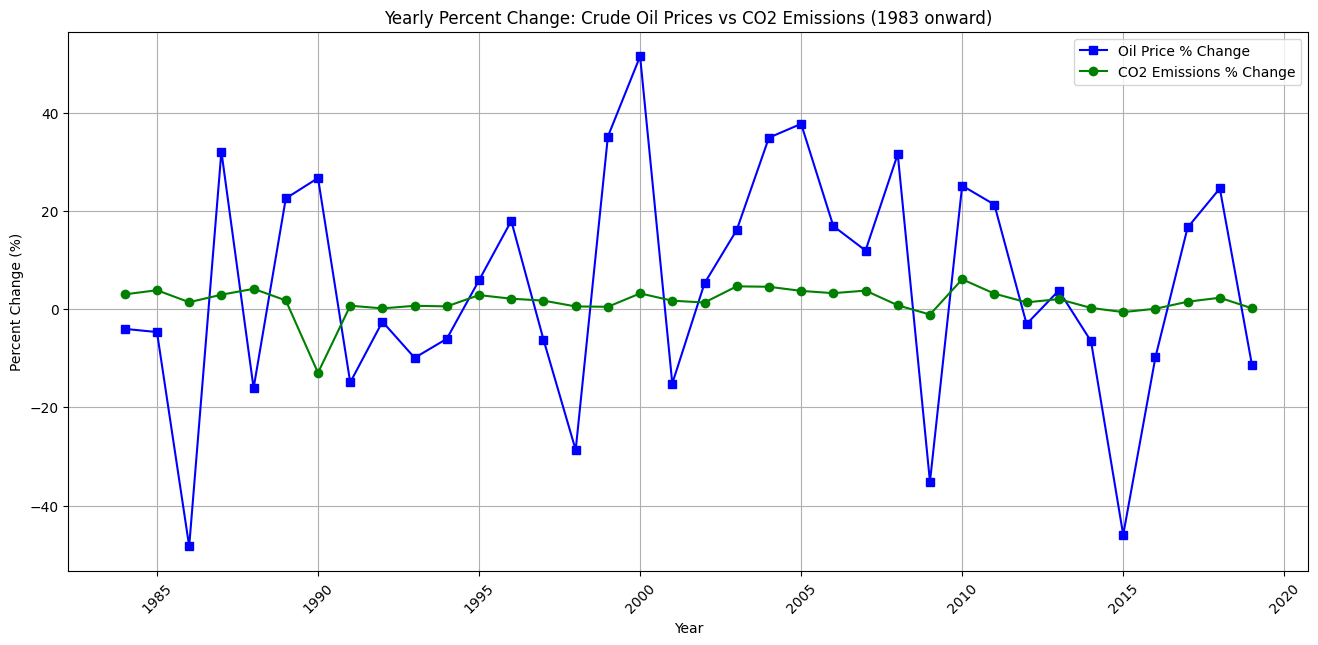

In [38]:
plt.figure(figsize=(16,7))

# Plot percent changes
plt.plot(merged_df['year'], merged_df['price_pct_change'], marker='s', color='blue', label='Oil Price % Change')
plt.plot(merged_df['year'], merged_df['CO2_pct_change'], marker='o', color='green', label='CO2 Emissions % Change')

# Titles and labels
plt.title('Yearly Percent Change: Crude Oil Prices vs CO2 Emissions (1983 onward)')
plt.xlabel('Year')
plt.ylabel('Percent Change (%)')
plt.grid(True)
plt.legend()
plt.xticks(rotation=45)

plt.show()


### Analysis of Yearly Percent Changes

The yearly percent-change chart provides a **numerical view of how CO₂ emissions and crude oil prices vary annually**.

**Key observations:**

- **Oil prices fluctuate much more dramatically** year-to-year than CO₂ emissions.  
  - Large spikes and drops are visible in years like 2008, 2015, and 2020.  
- **CO₂ emissions are much steadier**, with smaller percent changes, reflecting that global emissions respond **gradually** to economic and energy supply fluctuations.  
- **Lag effects are visible**:
  - The 2015 oil price drop did not immediately reduce emissions; only a slight dip occurs in 2016.  
  - This highlights how industrial activity, energy use, and policy decisions **buffer emissions from short-term price shocks**.
- **Periods of alignment**:
  - The 2008 financial crisis shows a minor dip in emissions following the spike in oil prices.  
  - The 2020 COVID-19 crash is a clear exception, where both oil prices and emissions dropped sharply, showing that **extreme disruptions can simultaneously impact both datasets**.

**Interpretation:**

- Overall, CO₂ emissions are **partially decoupled from crude oil price volatility**.  
- Percent-change analysis reinforces our visual observations from the dual-axis chart: **emissions respond slowly** to economic or energy market shocks but extreme events can create noticeable short-term effects.


## Sustainable Energy (2000-2020)

### Overview & Plan — Sustainable Energy (2000–2020)

Goal: bring in the **Global Data on Sustainable Energy** dataset and get it clean enough for analysis alongside oil prices and CO₂ emissions.

This dataset provides global indicators related to sustainable energy, energy access, renewable energy adoption, and related socio-economic variables.  

It includes metrics such as:  
- **Access to electricity** (% of population)  
- **Access to clean fuels for cooking** (% of population)  
- **Renewable electricity capacity per capita**  
- **Financial flows to developing countries (USD)**  
- **Energy mix** (electricity from fossil fuels, nuclear, renewables)  
- **CO₂ emissions by country (kt)**  
- **GDP growth and GDP per capita**  
- **Geospatial attributes** (latitude, longitude, land area, population density)  

In [4]:
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)

df_energy_raw = pd.read_csv('global-data-on-sustainable-energy.csv')

print("Shape:", df_energy_raw.shape)
print("\nColumns:")
print(list(df_energy_raw.columns))

print("\nHead:")
display(df_energy_raw.head(10))

print("\nInfo:")
print(df_energy_raw.info())

Shape: (3649, 21)

Columns:
['Entity', 'Year', 'Access to electricity (% of population)', 'Access to clean fuels for cooking', 'Renewable-electricity-generating-capacity-per-capita', 'Financial flows to developing countries (US $)', 'Renewable energy share in the total final energy consumption (%)', 'Electricity from fossil fuels (TWh)', 'Electricity from nuclear (TWh)', 'Electricity from renewables (TWh)', 'Low-carbon electricity (% electricity)', 'Primary energy consumption per capita (kWh/person)', 'Energy intensity level of primary energy (MJ/$2017 PPP GDP)', 'Value_co2_emissions_kt_by_country', 'Renewables (% equivalent primary energy)', 'gdp_growth', 'gdp_per_capita', 'Density\\n(P/Km2)', 'Land Area(Km2)', 'Latitude', 'Longitude']

Head:


,Entity,Year,Access to electricity (% of population),Access to clean fuels for cooking,Renewable-electricity-generating-capacity-per-capita,Financial flows to developing countries (US $),Renewable energy share in the total final energy consumption (%),Electricity from fossil fuels (TWh),Electricity from nuclear (TWh),Electricity from renewables (TWh),Low-carbon electricity (% electricity),Primary energy consumption per capita (kWh/person),Energy intensity level of primary energy (MJ/$2017 PPP GDP),Value_co2_emissions_kt_by_country,Renewables (% equivalent primary energy),gdp_growth,gdp_per_capita,Density\n(P/Km2),Land Area(Km2),Latitude,Longitude
0,Afghanistan,2000,1.613591,6.20,9.22,20000.0,44.99,0.16,0.0,0.31,65.957440,302.59482,1.64,760.000000,NaN,NaN,NaN,60,652230.0,33.93911,67.709953
1,Afghanistan,2001,4.074574,7.20,8.86,130000.0,45.60,0.09,0.0,0.50,84.745766,236.89185,1.74,730.000000,NaN,NaN,NaN,60,652230.0,33.93911,67.709953
2,Afghanistan,2002,9.409158,8.20,8.47,3950000.0,37.83,0.13,0.0,0.56,81.159424,210.86215,1.40,1029.999971,NaN,NaN,179.426579,60,652230.0,33.93911,67.709953
3,Afghanistan,2003,14.738506,9.50,8.09,25970000.0,36.66,0.31,0.0,0.63,67.021280,229.96822,1.40,1220.000029,NaN,8.832278,190.683814,60,652230.0,33.93911,67.709953
4,Afghanistan,2004,20.064968,10.90,7.75,NaN,44.24,0.33,0.0,0.56,62.921350,204.23125,1.20,1029.999971,NaN,1.414118,211.382074,60,652230.0,33.93911,67.709953
5,Afghanistan,2005,25.390894,12.20,7.51,9830000.0,33.88,0.34,0.0,0.59,63.440857,252.06912,1.41,1549.999952,NaN,11.229715,242.031313,60,652230.0,33.93911,67.709953
6,Afghanistan,2006,30.718690,13.85,7.40,10620000.0,31.89,0.20,0.0,0.64,76.190475,304.42090,1.50,1759.999990,NaN,5.357403,263.733602,60,652230.0,33.93911,67.709953
7,Afghanistan,2007,36.051010,15.30,7.25,15750000.0,28.78,0.20,0.0,0.75,78.947370,354.27990,1.53,1769.999981,NaN,13.826320,359.693158,60,652230.0,33.93911,67.709953
8,Afghanistan,2008,42.400000,16.70,7.49,16170000.0,21.17,0.19,0.0,0.54,73.972600,607.83350,1.94,3559.999943,NaN,3.924984,364.663542,60,652230.0,33.93911,67.709953
9,Afghanistan,2009,46.740050,18.40,7.50,9960000.0,16.53,0.16,0.0,0.78,82.978720,975.04816,2.25,4880.000114,NaN,21.390528,437.268740,60,652230.0,33.93911,67.709953



Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3649 entries, 0 to 3648
Data columns (total 21 columns):
 #   Column                                                            Non-Null Count  Dtype  
---  ------                                                            --------------  -----  
 0   Entity                                                            3649 non-null   object 
 1   Year                                                              3649 non-null   int64  
 2   Access to electricity (% of population)                           3639 non-null   float64
 3   Access to clean fuels for cooking                                 3480 non-null   float64
 4   Renewable-electricity-generating-capacity-per-capita              2718 non-null   float64
 5   Financial flows to developing countries (US $)                    1560 non-null   float64
 6   Renewable energy share in the total final energy consumption (%)  3455 non-null   float64
 7   Electricity from fossil fu